# Analyzing US Traffic Crashes

## Overview

This project analyzes millions of car crashes to highlight insights related to crash frequency at certain days of the week and times of day, how the impact distance of crashes relates to their severity and street type, and how road design features impact the severity of crashes. This provides actionable strategies for those responding to crashes and those designing road features, in order to proactively allocate resources and proactively improve road design to prevent crashes before they happen.

## Business Understanding

### Data Source

The data used is this project is from the Kaggle dataset found at https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents. This dataset encompasses car crash data from 49 states from February 2016 through March 2023, and includes approximately 7.7 million records.

### Questions to Answer

While there is a wide variety of analysis that could be done on this data, this analysis focuses on a few key points:
* Are crashes concentrated at particular days of the week and times of day?
* How does the impact distance of crashes relate to their severity, and does this vary based on whether the crash took place on a highway or local street?
* How does the presence or absence of road design features impact the severity of crashes?

### Benefits and Goals

Understand the answers to these questions can aid in more effective responses to crashes, and in more carefully designed roads to help prevent crashes from happening at all. Having a more effective response to the crashes that do happen, whatever their severity level, so that traffic doesn't build up behind them and potentially lead to additional crashes and delays. Concentrating resources at specific times and to specific locations can also aid in planning and budgeting for when personnel and equipment resources are most likely to actually be utilized. Improving road design can help mitigate crashes from happening in the future, reducing the damage to vehicles and humans, and reducing the amount of response resources needed.

### Stakeholders

There are two primary stakeholder groups for this analysis: the people who control the response to crashes, and the people who control the design of streets.

This can vary based on region, and may have overlap. The groups who control the response to crashes could be as large as a state-level highway police force, or as small as a local sheriff's office. The groups who control the design of streets could be as large as a state-level Department of Transportation, or as small as a local community board.

The former group is focused on responding to crashes and clearing them quickly, so that secondary impacts (slow traffic, inattention, etc.) are felt by a minimal number of additional drivers. The latter group is focused on preventing crashes from happening as frequently in the first place.

## Data Understanding

The data can be reviewed to get a baseline understanding. This helps determine which features need to be cleaned or derived in order to be most useful. This also shows initial patterns that can be explored in more detail later in the project.

In [1]:
# Imports

# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import regex as r

# Statistics
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.stats import mannwhitneyu
import statsmodels.api as sm

In [2]:
# Load the data into a DataFrame
raw_data = pd.read_csv('US_Accidents_March23.csv')

raw_data.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
# Examine the data
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [4]:
# Examine the data
raw_data.describe(include='all')

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,7728394,7728394,7.728394e+06,7728394,7728394,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,...,7728394,7728394,7728394,7728394,7728394,7728394,7705148,7705148,7705148,7705148
unique,7728394,3,NaN,6131796,6705355,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,1,2,2,2,2
top,A-1,Source1,NaN,2021-01-26 16:16:13,2021-11-22 08:00:00,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,Day,Day,Day,Day
freq,1,4325632,NaN,225,112,NaN,NaN,NaN,NaN,NaN,...,7728145,7526493,7514023,7720796,6584622,7728394,5334553,5695619,6076156,6377548
mean,NaN,NaN,2.212384e+00,NaN,NaN,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,4.875313e-01,NaN,NaN,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000e+00,NaN,NaN,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.000000e+00,NaN,NaN,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2.000000e+00,NaN,NaN,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.000000e+00,NaN,NaN,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Check for missing values
raw_data.isna().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [6]:
# Get the value counts for categorical columns
# Exclude Airport_Code because there are >2000 values represented
# Exclude Country because 'US' is the only value represented
categorical_cols = [
    'Source',
    'Severity',
    'State',
    'Timezone',
    'Wind_Direction',
    'Weather_Condition'
]

for category in categorical_cols:
    print(raw_data[category].value_counts())
    print('\n')

Source
Source1    4325632
Source2    3305373
Source3      97389
Name: count, dtype: int64


Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
LA     149701
NJ     140719
MD     140417
OH     118115
WA     108221
AL     101044
UT      97079
CO      90885
OK      83647
MO      77323
CT      71005
IN      67224
MA      61996
WI      34688
KY      32254
NE      28870
MT      28496
IA      26307
AR      22780
NV      21665
KS      20992
DC      18630
RI      16971
MS      15181
DE      14097
WV      13793
ID      11376
NM      10325
NH      10213
WY       3757
ND       3487
ME       2698
VT        926
SD        289
Name: count, dtype: int64


Timezone
US/Eastern     3580167
US/Pacific     2062984
US/Central     1645616
US/Mountain     43181

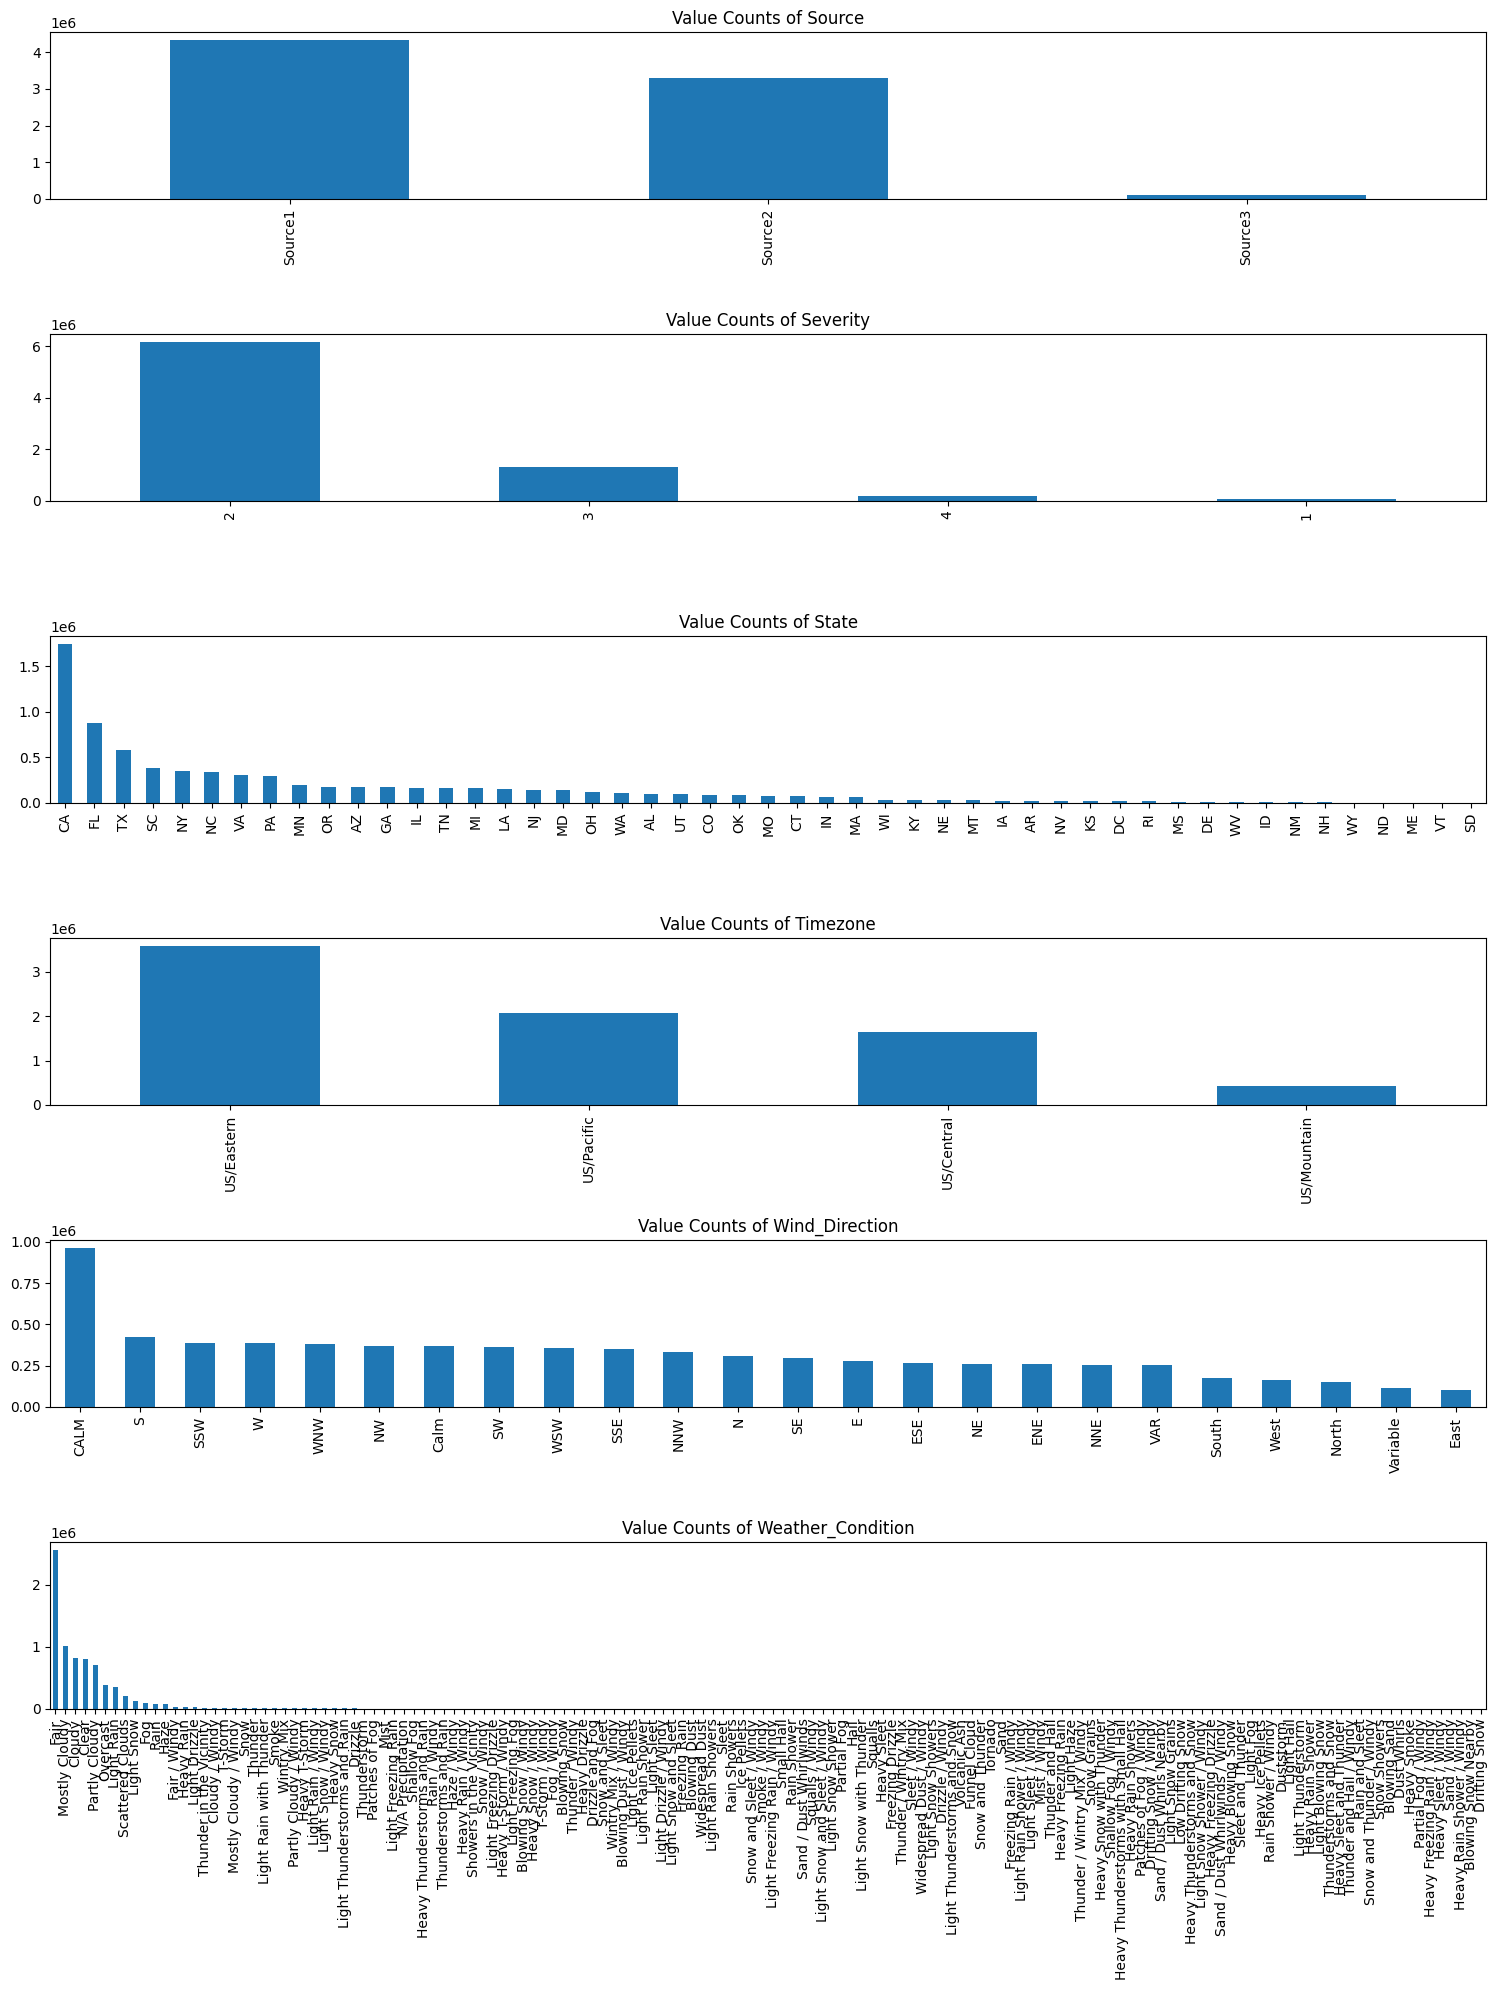

In [7]:
# Plot column charts of categorical columns
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(15,20))
axe = axes.ravel()
for i, categorical_col in enumerate(categorical_cols):
    raw_data[categorical_col].value_counts().plot(kind='bar', ax=axe[i])
    axe[i].set_title(f'Value Counts of {categorical_col}')
    axe[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [8]:
# Get the value counts for binary columns
binary_cols = [
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Turning_Loop',
    'Sunrise_Sunset',
    'Civil_Twilight',
    'Nautical_Twilight',
    'Astronomical_Twilight'
]

for binary_col in binary_cols:
    print(raw_data[binary_col].value_counts())
    print('\n')

Amenity
False    7632060
True       96334
Name: count, dtype: int64


Bump
False    7724880
True        3514
Name: count, dtype: int64


Crossing
False    6854631
True      873763
Name: count, dtype: int64


Give_Way
False    7691812
True       36582
Name: count, dtype: int64


Junction
False    7157052
True      571342
Name: count, dtype: int64


No_Exit
False    7708849
True       19545
Name: count, dtype: int64


Railway
False    7661415
True       66979
Name: count, dtype: int64


Roundabout
False    7728145
True         249
Name: count, dtype: int64


Station
False    7526493
True      201901
Name: count, dtype: int64


Stop
False    7514023
True      214371
Name: count, dtype: int64


Traffic_Calming
False    7720796
True        7598
Name: count, dtype: int64


Traffic_Signal
False    6584622
True     1143772
Name: count, dtype: int64


Turning_Loop
False    7728394
Name: count, dtype: int64


Sunrise_Sunset
Day      5334553
Night    2370595
Name: count, dtype: int64


Civil_Twil

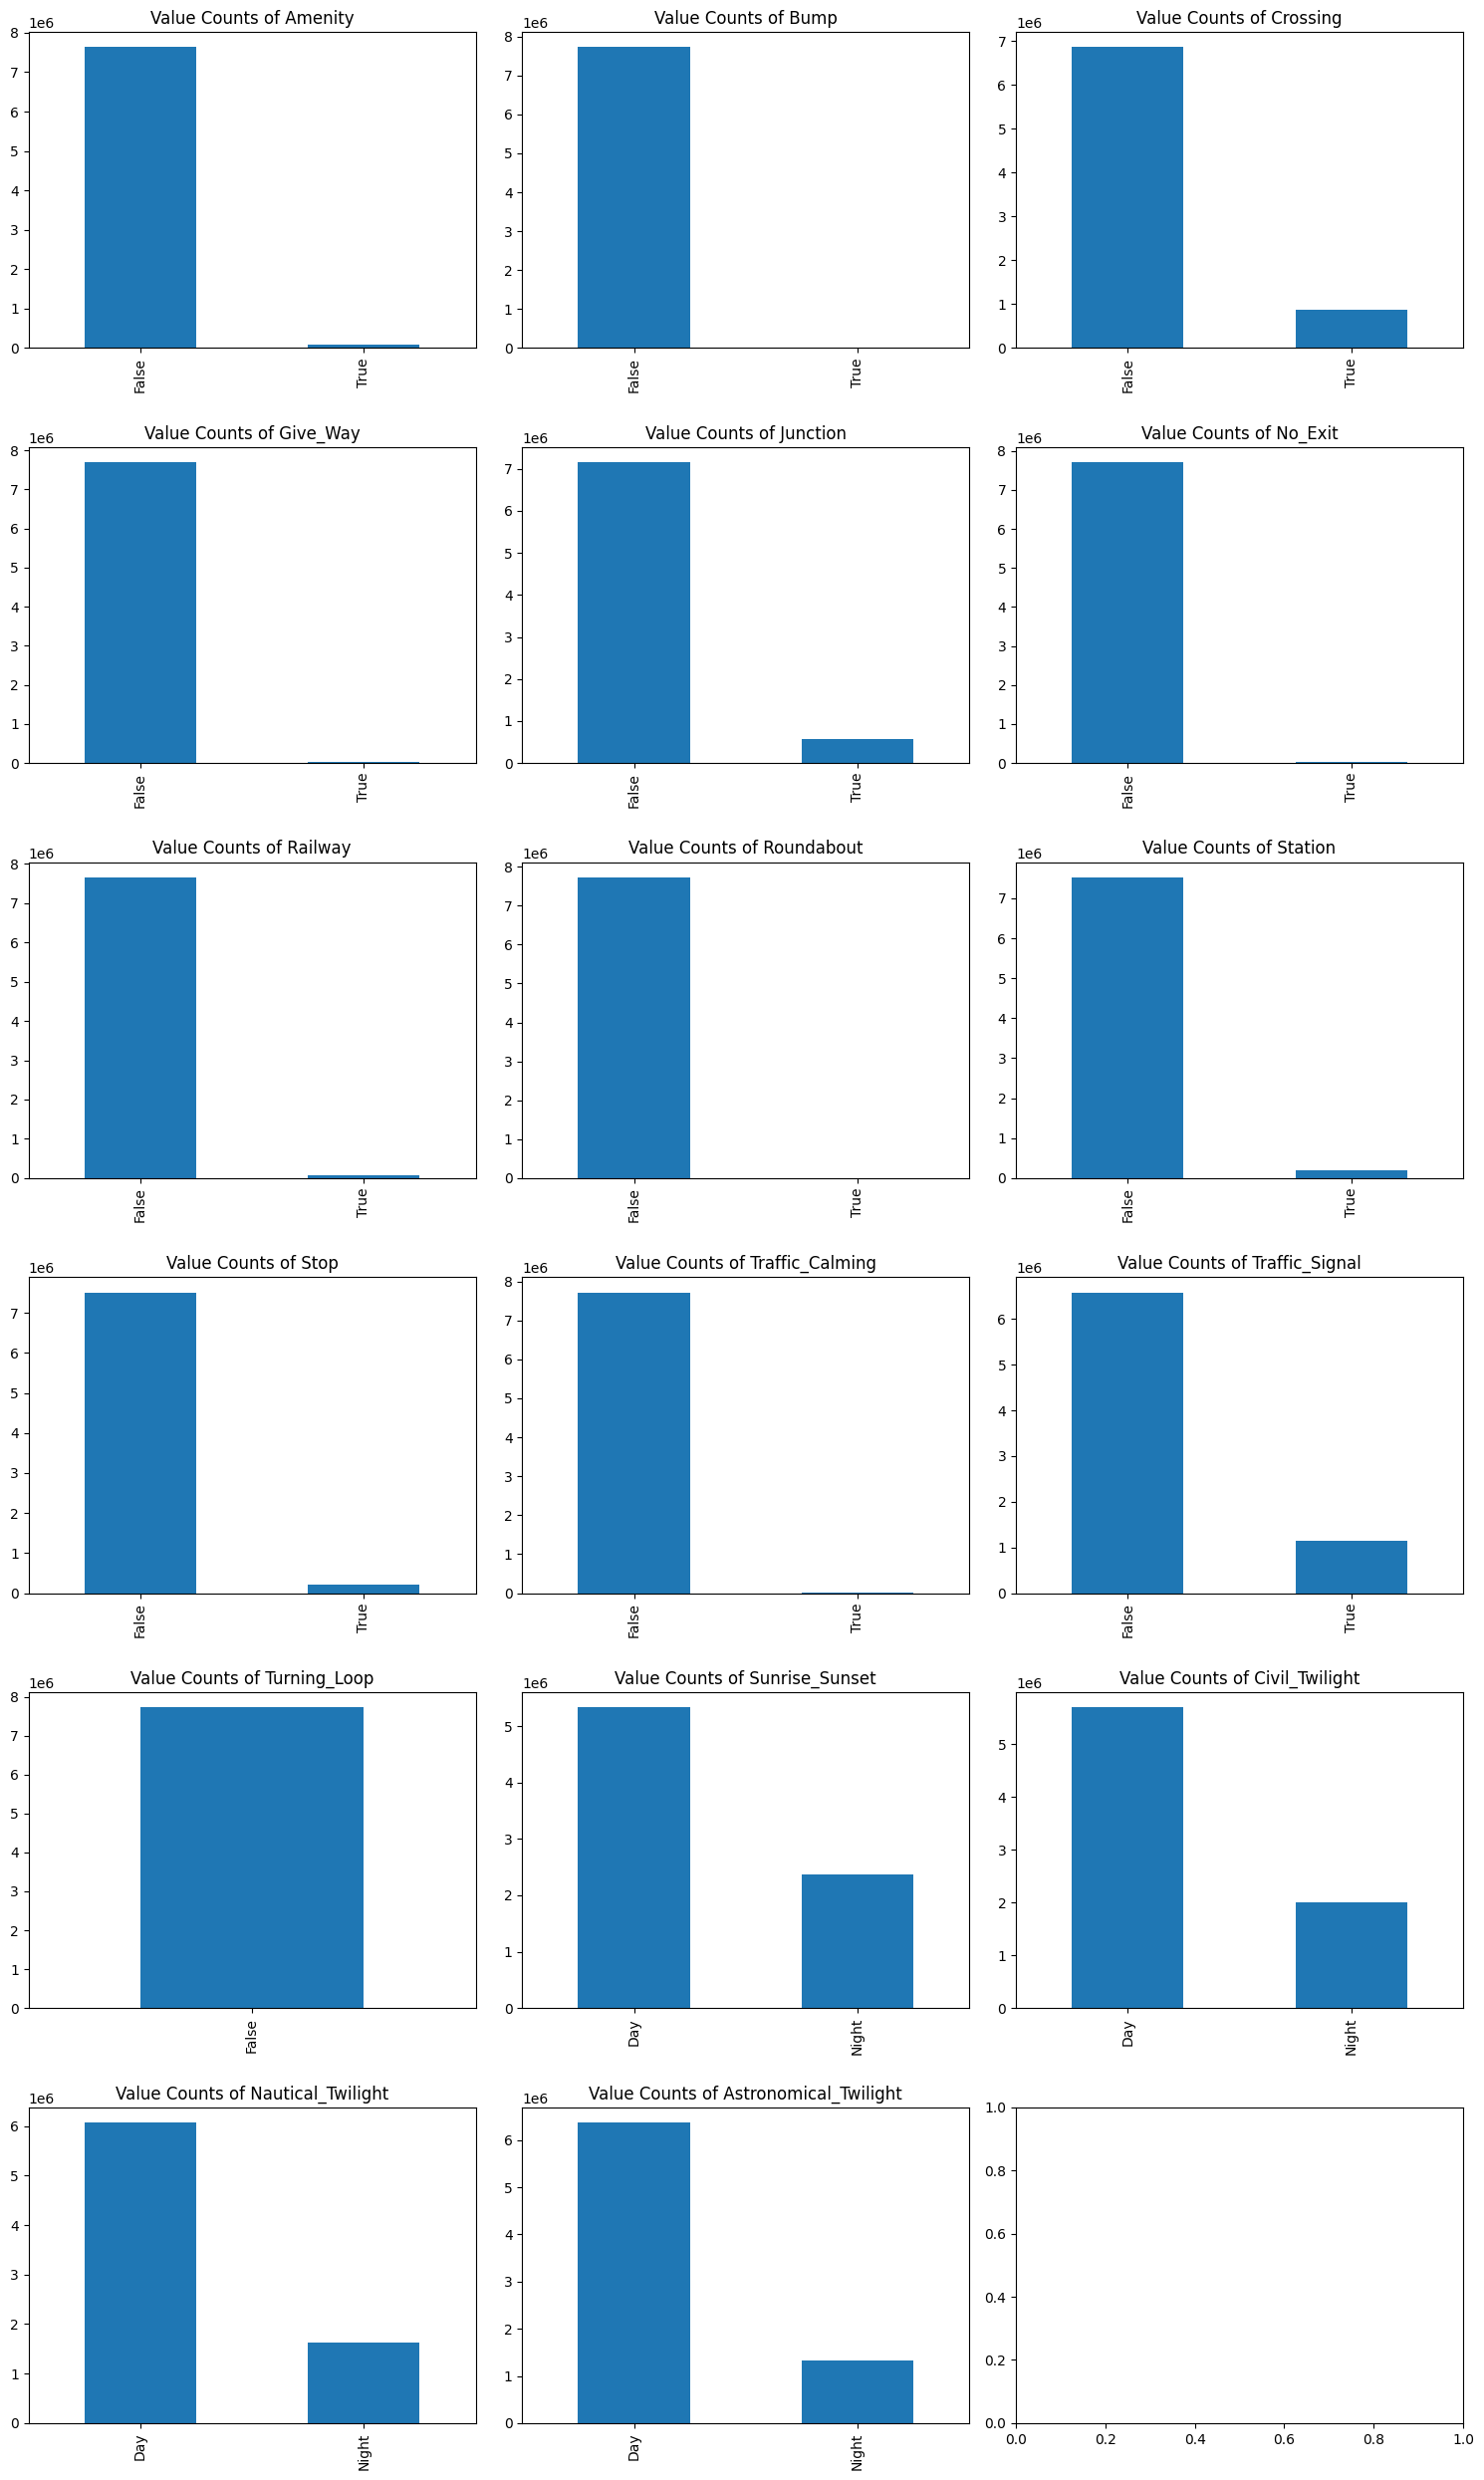

In [9]:
# Plot column charts of binary columns
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15,25))
axe = axes.ravel()
for i, binary_col in enumerate(binary_cols):
    raw_data[binary_col].value_counts().plot(kind='bar', ax=axe[i])
    axe[i].set_title(f'Value Counts of {binary_col}')
    axe[i].set_xlabel('')


plt.tight_layout()
plt.show()

In [10]:
# Identify numerical columns
numerical_cols = [
    'Start_Lat',
    'Start_Lng',
    'End_Lat',
    'End_Lng',
    'Distance(mi)',
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)'
]

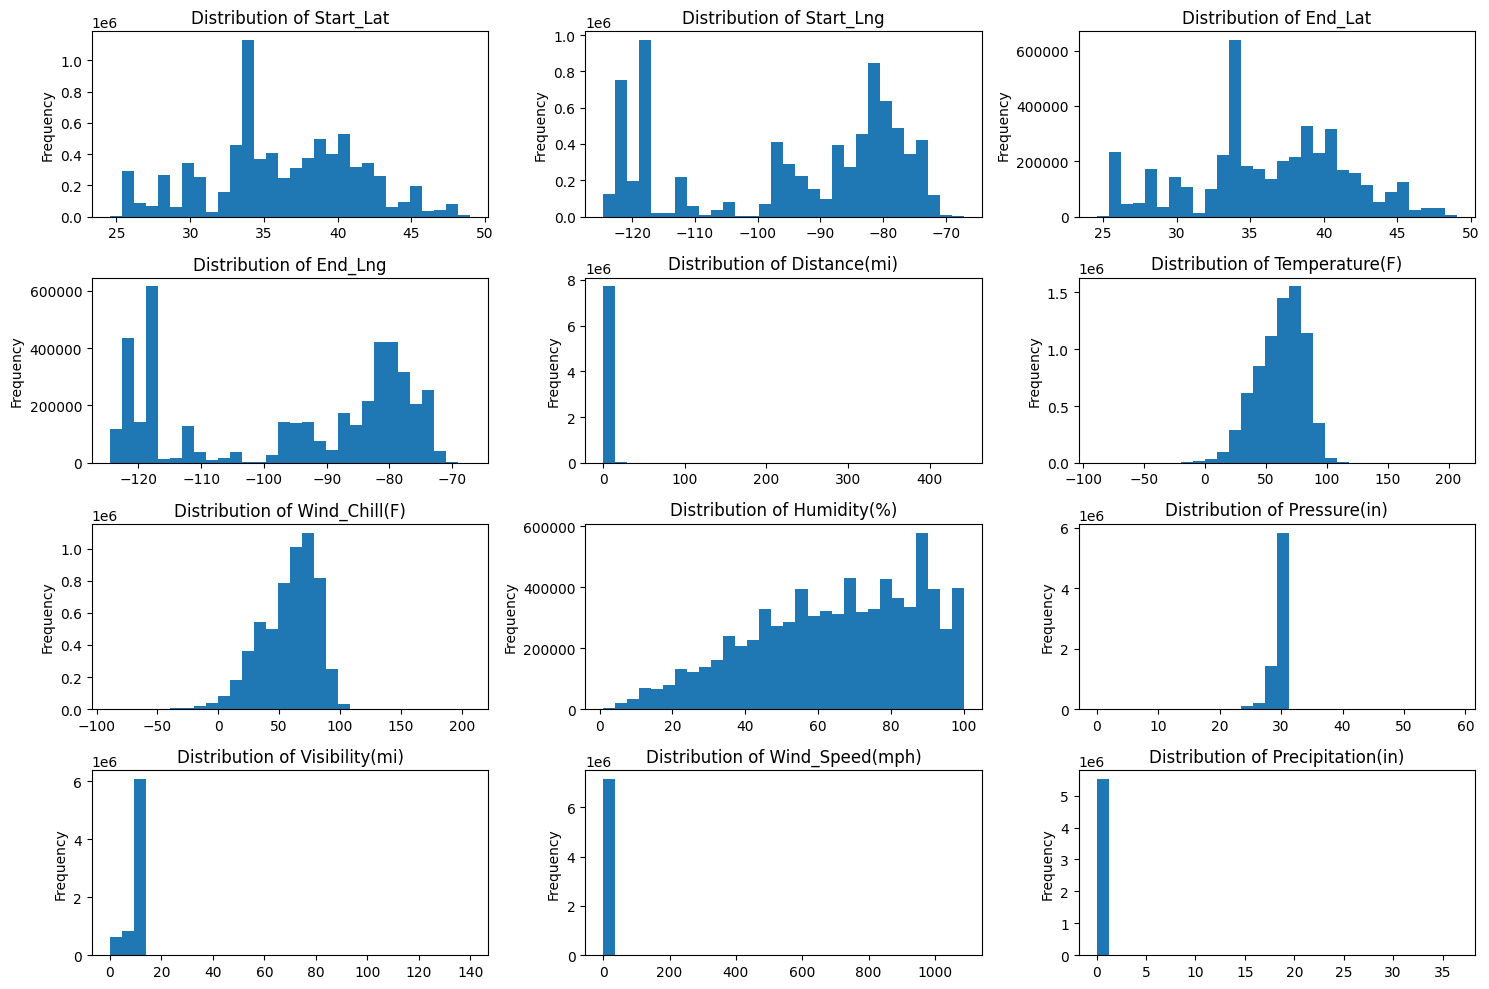

In [11]:
# Plot histograms of numerical columns
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15,10))
axe = axes.ravel()
for i, num_col in enumerate(numerical_cols):
    raw_data[num_col].plot(kind='hist', bins=30, ax=axe[i])
    axe[i].set_title(f'Distribution of {num_col}')
    axe[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Data Preparation

The initial data exploration above revealed a few areas of data cleaning that must be performed before the data is analyzed.

There are many null values in the data set. Of the ones with more than 100,000 null values:
* End_Lat and End_Lng: These are likely very similar to Start_Lat and Start_Lng and so do not need to be imputed.
* Wind_Chill: Temperature has many fewer missing values (153853) than Wind Chill (1999019), so Temperature can likely be used instead.

There are some pieces of data that we are unlikely to be relevant to our analysis and can be ignored.
* Most car crashes happen very quickly, so End_Time is likely very similar to Start_Time.
* Since the data comes from all over the country, latitude and longitude data is too granular for the level of analysis being done.
* The entirety of the data is from the United States, so the Country field is not needed.
* Airport Code refers to the airport-based weather station closest to the accident. Again, because the data comes from all over the country, it is unlikely any Airport Codes appear frequently enough to be relevant.
* Weather_Timestamp is likely roughly duplicative of Start_Time.
* Civil_Twilight, Nautical_Twilight, and Astronomical_Twilight are variations on Sunrise_Sunset with slightly different parameters, but all have roughly the same values.

There are some features that can be derived from existing features:
* Streets can be split into "highway" and "local" based on their name.
* Wind_Direction is recorded with varying names ("E" vs. "East"), so these can be consolidated.
* Start_Time can be split out to its component parts of year, month, day, and hour. Day of week can also be split out.
* Weather_Condition contains some combinations, so these can be one-hot encoded.

In [12]:
# Make a copy of the data to clean
data = raw_data.copy()

# Drop the columns mentioned above to remove unneeded columns
columns_to_drop = [
    'Start_Lat',
    'Start_Lng',
    'End_Lat',
    'End_Lng',
    'Wind_Chill(F)',
    'End_Time',
    'Country',
    'Airport_Code',
    'Weather_Timestamp',
    'Civil_Twilight',
    'Nautical_Twilight',
    'Astronomical_Twilight'
]

data.drop(columns_to_drop, axis=1, inplace=True)

data.head()

,ID,Source,Severity,Start_Time,Distance(mi),Description,Street,City,County,State,...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset
0,A-1,Source2,3,2016-02-08 05:46:00,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,...,False,False,False,False,False,False,False,False,False,Night
1,A-2,Source2,2,2016-02-08 06:07:59,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,...,False,False,False,False,False,False,False,False,False,Night
2,A-3,Source2,2,2016-02-08 06:49:27,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,...,False,False,False,False,False,False,False,True,False,Night
3,A-4,Source2,3,2016-02-08 07:23:34,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,...,False,False,False,False,False,False,False,False,False,Night
4,A-5,Source2,2,2016-02-08 07:39:07,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,...,False,False,False,False,False,False,False,True,False,Day


In [13]:
# Clean the data for Wind_Direction, to convert all to abbreviated directions and consolidate "calm" and "variable"
data['Wind_Direction'] = data['Wind_Direction'].replace({'CALM': 'Calm', 'East': 'E', 'North': 'N', 'South': 'S', 'VAR': 'Variable', 'West': 'W'})
data['Wind_Direction'].value_counts().sort_index()

Wind_Direction
Calm        1330181
E            382459
ENE          258474
ESE          268311
N            460536
NE           258639
NNE          255311
NNW          333427
NW           369352
S            597364
SE           294901
SSE          349110
SSW          384840
SW           364470
Variable     364562
W            548664
WNW          378781
WSW          353806
Name: count, dtype: int64

In [14]:
# Clean the data for Weather_Condition to split apart multiple conditions and convert these to one-hot encoding

# Replace "x and y" weather conditions with "x / y" so all values match
data['Weather_Condition'] = data['Weather_Condition'].str.replace(' and ', ' / ').str.strip()

# Split values at " / " and make separate columns
weather_data = data['Weather_Condition'].str.get_dummies(sep=' / ')

data = pd.concat([data, weather_data], axis=1)

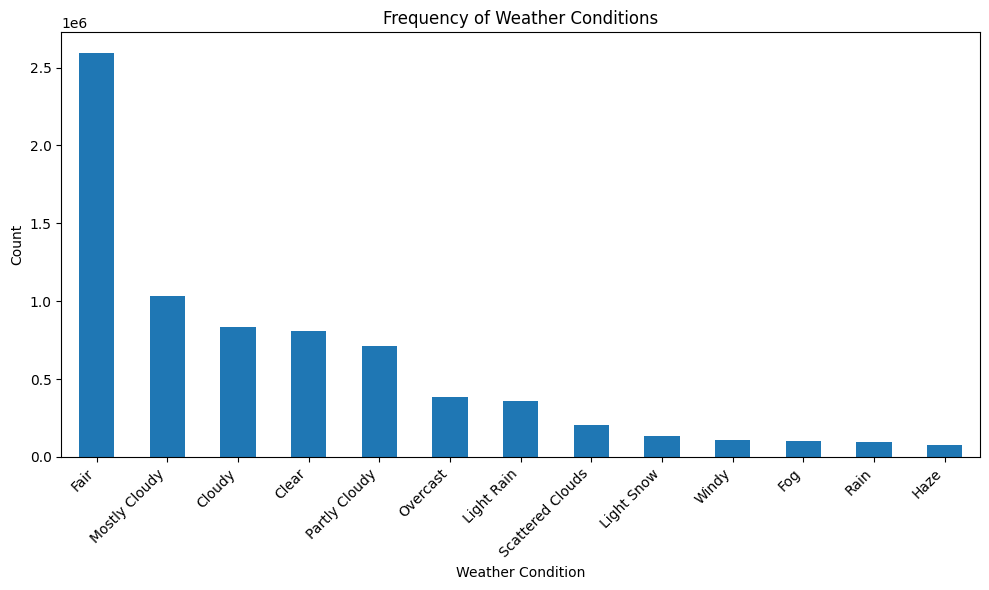

In [15]:
# Plot the cleaned up weather conditions to better visualize

# Sum the columns to get the total count for each column
weather_counts = weather_data.sum().sort_values(ascending=False)

# Filter out weather conditions that appear less than 70,000 times in the 7+ million records (<1%)
top_weather_counts = weather_counts[weather_counts > 70000]

# Create a bar chart
top_weather_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Frequency of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Start_Time should be split into date and time components

# Convert the columns to datetime objects
data['Start_Time'] = pd.to_datetime(data['Start_Time'], format='ISO8601', errors='coerce')

# Extract year, month, day, day of week, and hour into new columns
data['Year']  = data['Start_Time'].dt.year
data['Month'] = data['Start_Time'].dt.month
data['Day']   = data['Start_Time'].dt.day
data['Day_of_Week'] = data['Start_Time'].dt.dayofweek
data['Hour']  = data['Start_Time'].dt.hour

# Check the results
data[['Start_Time', 'Year', 'Month', 'Day', 'Day_of_Week', 'Hour']].head()


,Start_Time,Year,Month,Day,Day_of_Week,Hour
0,2016-02-08 05:46:00,2016,2,8,0,5
1,2016-02-08 06:07:59,2016,2,8,0,6
2,2016-02-08 06:49:27,2016,2,8,0,6
3,2016-02-08 07:23:34,2016,2,8,0,7
4,2016-02-08 07:39:07,2016,2,8,0,7


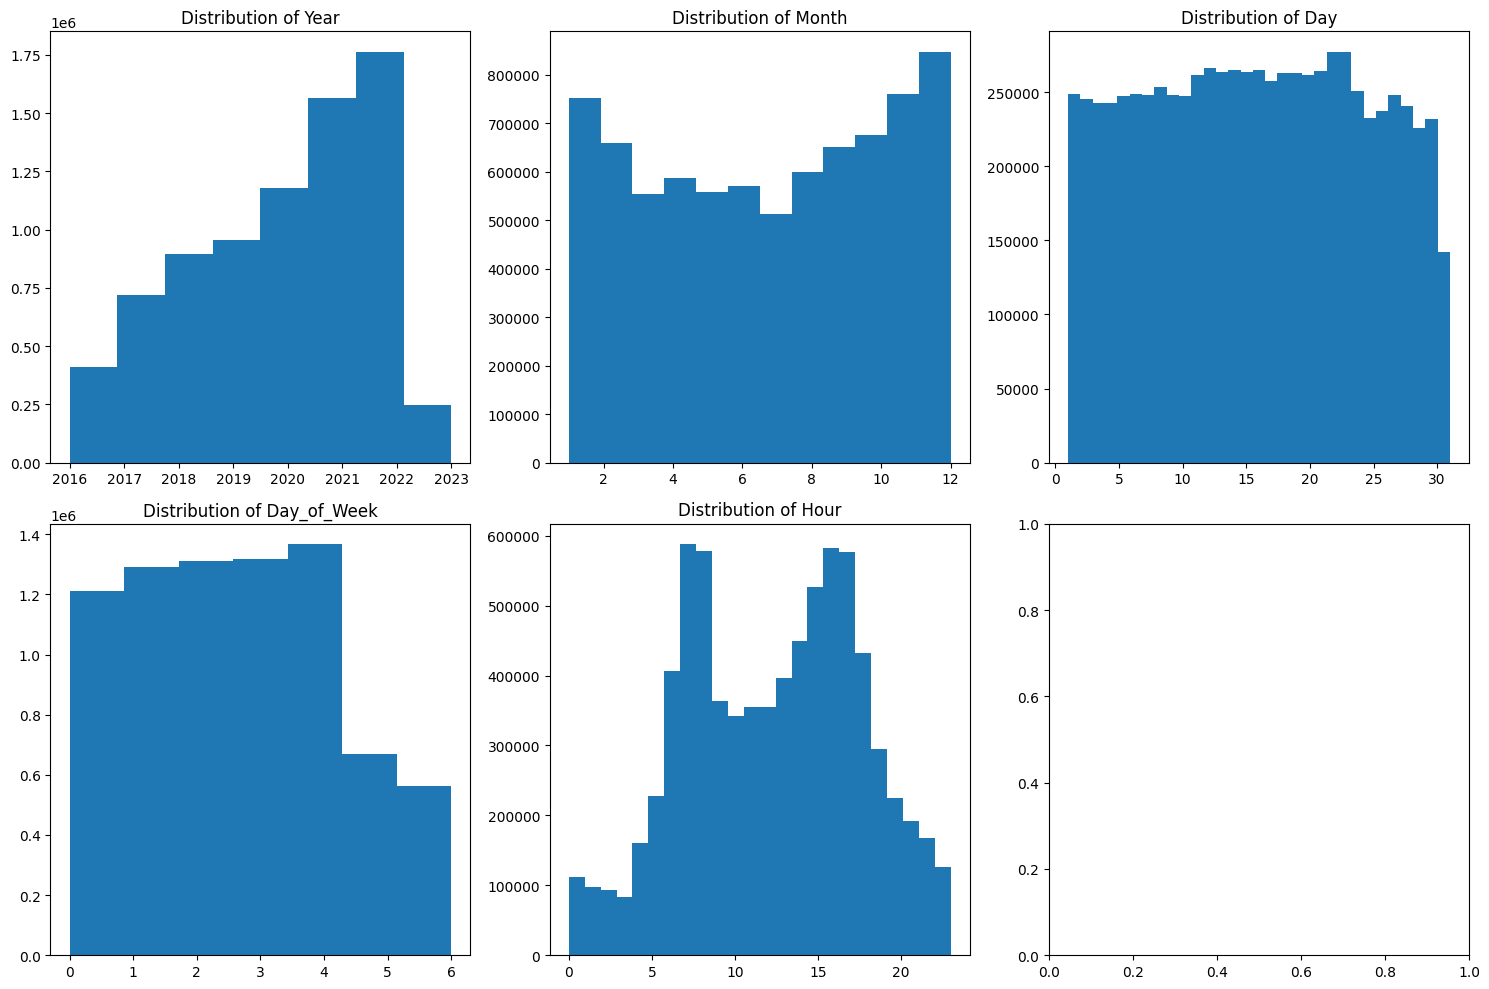

In [17]:
# Plot histograms of new date/time columns
date_columns = [
    'Year',
    'Month',
    'Day',
    'Day_of_Week',
    'Hour'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

axes[0,0].hist(data['Year'], bins=8)
axes[0,0].set_title('Distribution of Year')

axes[0,1].hist(data['Month'], bins=12)
axes[0,1].set_title('Distribution of Month')

axes[0,2].hist(data['Day'], bins=31)
axes[0,2].set_title('Distribution of Day')

axes[1,0].hist(data['Day_of_Week'], bins=7)
axes[1,0].set_title('Distribution of Day_of_Week')

axes[1,1].hist(data['Hour'], bins=24)
axes[1,1].set_title('Distribution of Hour')

plt.tight_layout()
plt.show()

In [18]:
# Group streets by assumed road type
# Strip the values to remove extra spaces
data['Street'] = data['Street'].str.strip()

# Use regex to define the pattern to look for: starting with "I-", "US-", "CA-", "GA-", "FL-"; or containing "Fwy", "Tpke", "Expy", "Pkwy", "Beltway", "Hwy", "Highway"
regex_pattern = r'^(I-|US-|CA-|GA-|FL-)|\b(Fwy|Tpke|Expy|Pkwy|Beltway|Hwy|Highway)\b'

# Create the new column based on the regex pattern, assuming those that match are highways, and all others are local
data['Street_Type'] = np.where(
    data['Street'].str.contains(regex_pattern, case=False, na=False, regex=True),
    'highway',
    'local'
)

/var/folders/gq/b1tckqn91cvbfg9bjycs6t4c0000gp/T/ipykernel_97214/4253728098.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data['Street'].str.contains(regex_pattern, case=False, na=False, regex=True),


In [19]:
# Check the value counts and top values for each category
print(data['Street_Type'].value_counts())
print('\nTop 10 local streets')
print(data[data['Street_Type']=='local']['Street'].value_counts().nlargest(10))
print('\nTop 10 highways')
print(data[data['Street_Type']=='highway']['Street'].value_counts().nlargest(10))

Street_Type
local      3909058
highway    3819336
Name: count, dtype: int64

Top 10 local streets
Street
Main St                 12070
S Orange Blossom Trl     8804
N Main St                7566
E Main St                5955
SW 137th Ave             5551
S Main St                5424
SW 8th St                5225
W Main St                5104
Glenwood Ave             5093
Capital Blvd             5015
Name: count, dtype: int64

Top 10 highways
Street
I-95 N     78430
I-95 S     74528
I-5 N      71968
I-10 E     55573
I-10 W     53725
I-5 S      51781
I-80 W     39662
I-80 E     36113
I-405 N    32364
I-75 N     28166
Name: count, dtype: int64


## Analysis

Based on the initial data analysis done above, there are clear patterns to explore further. These include:

* Weekends (days 5 and 6) appear to have less frequent crashes than weekdays (days 0, 1, 2, 3, and 4).
* Morning rush hour (roughly 7am-9am) and evening rush hour (roughly 4pm-6pm) appear to have more frequent crashes than other times of day.
* The crash impact distance is heavily concentrated at 0, but might show more interesting patterns once values equal to 0 are removed.
* The majority of crashes do not have road design features (stop signs, etc.) present, but the presence or absence of these might contribute to how severe crashes are likely to be.

### Part 1: Analyze day of week and time of day

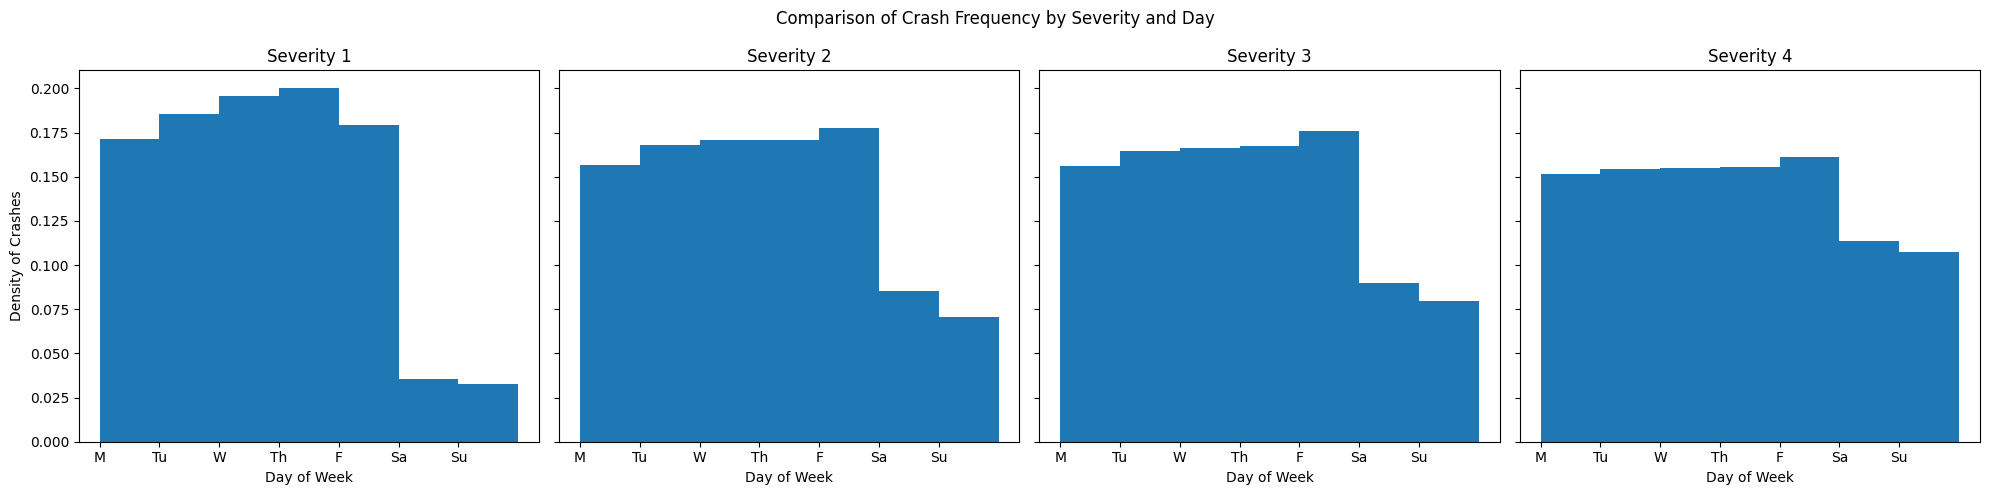

In [20]:
# Compare distributions of day of week based on crash severity

# Define the values for Severity
severity_levels = sorted(data['Severity'].unique())

# Create four subplots to compare
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True) # Use sharey=True for better scaling
for i, s in enumerate(severity_levels):
    subset = data[data['Severity'] == s]
    axes[i].hist(subset['Day_of_Week'], bins=7, range=(0, 7), density=True) # Use density=True to scale the data for better comparison
    axes[i].set_title(f'Severity {s}')
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(['M','Tu','W','Th','F','Sa','Su'])
    axes[i].set_xlabel('Day of Week')

axes[0].set_ylabel('Density of Crashes')
plt.suptitle('Comparison of Crash Frequency by Severity and Day')
plt.tight_layout()
plt.show()

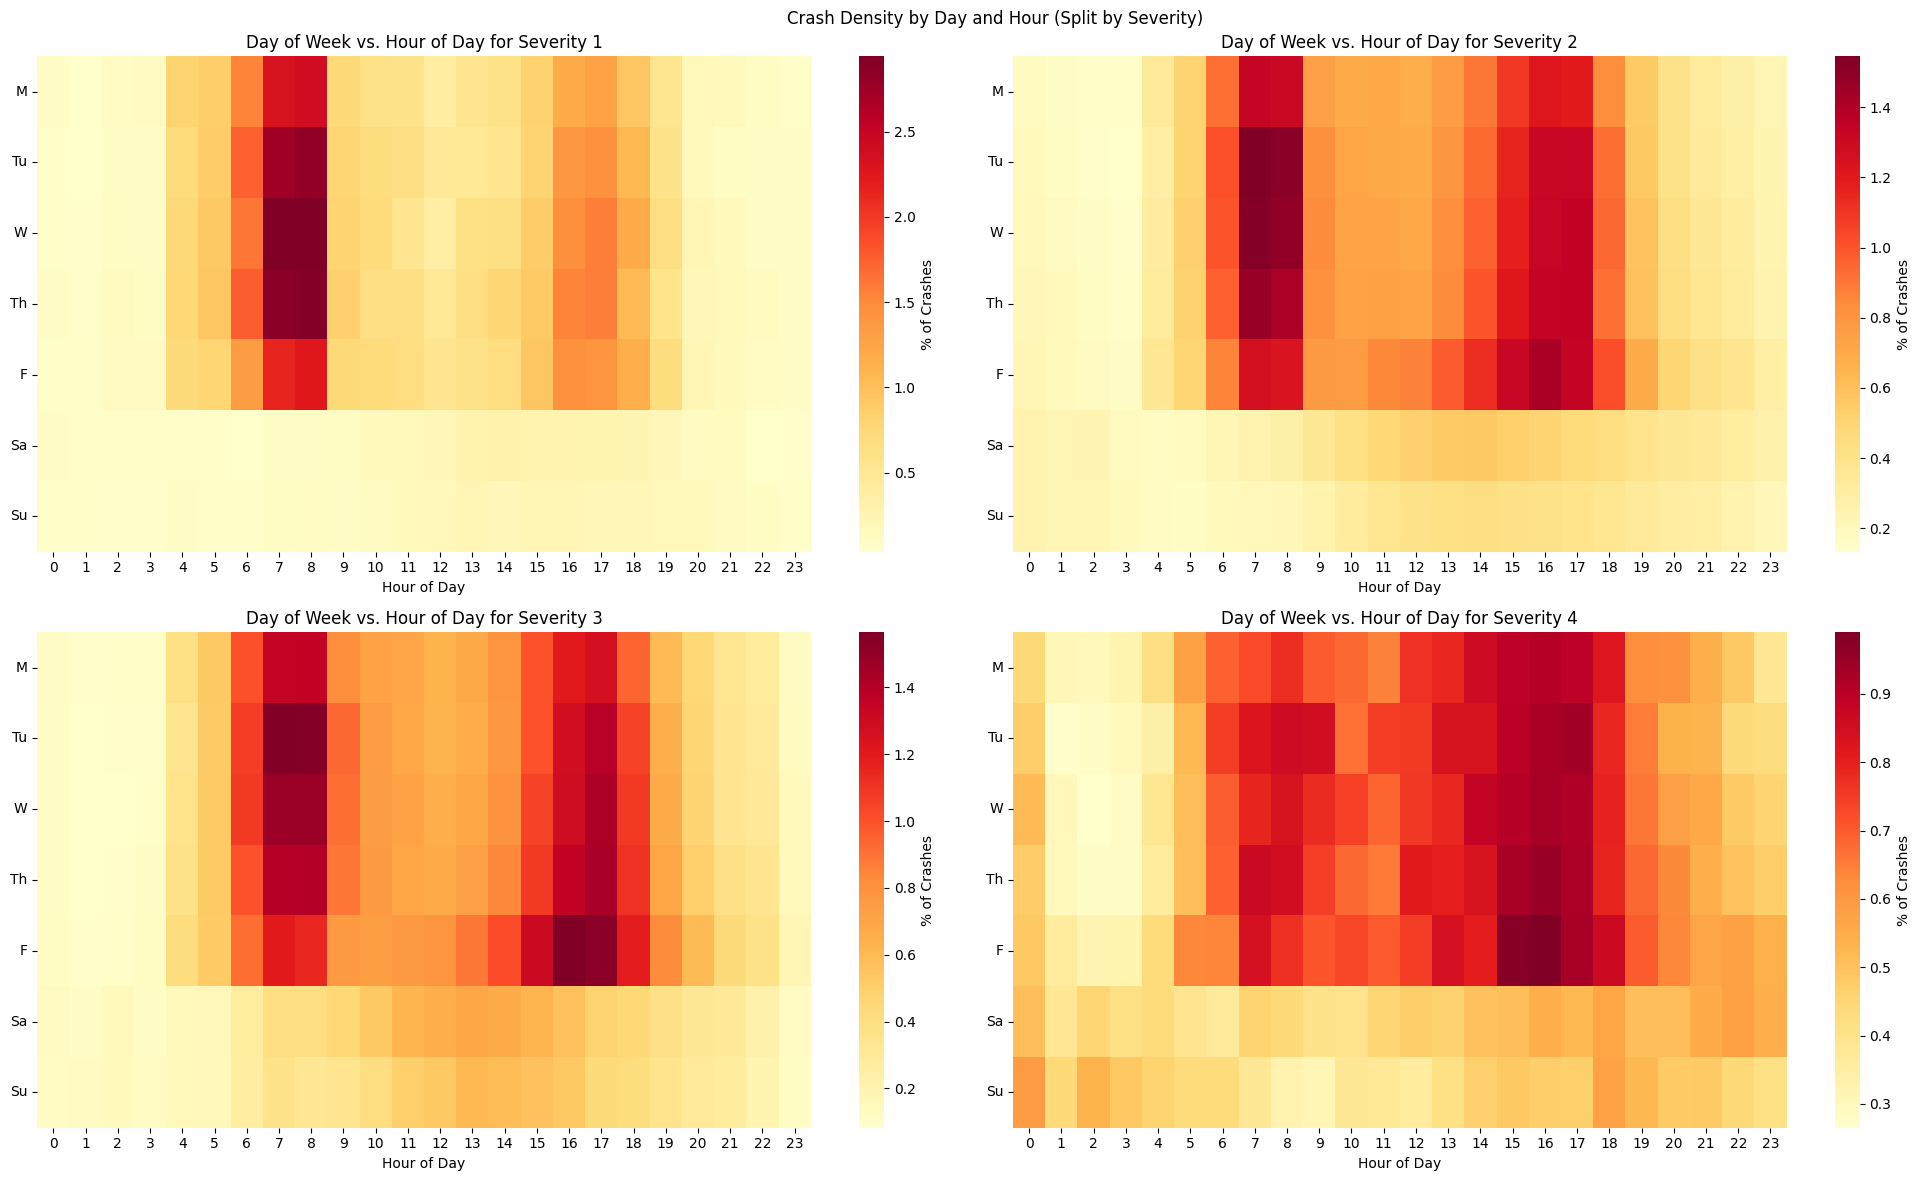

In [21]:
# Incorporate time of day as well as day of week, and split out by severity level

# Set up the subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, s in enumerate(severity_levels):
    subset = data[data['Severity'] == s]
    pivot = subset.groupby(['Day_of_Week', 'Hour']).size().unstack()
    
    # Normalize the data so patterns can be seen, since there are so many severity 2 crashes compared to other levels
    pivot_pct = (pivot / pivot.sum().sum()) * 100

    # Plot the heatmap on each subplot
    sns.heatmap(pivot_pct, ax=axes[i], cmap='YlOrRd', cbar_kws={'label': '% of Crashes'})
    
    axes[i].set_title(f'Day of Week vs. Hour of Day for Severity {s}')
    axes[i].set_yticklabels(['M','Tu','W','Th','F','Sa','Su'], rotation=0)
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('')

plt.suptitle('Crash Density by Day and Hour (Split by Severity)')
plt.tight_layout()
plt.show()

In [22]:
# Use a chi-square test to determine if day of week and hour are independent or if there is an association

# Create the contingency table, combining day of week and hour
data['Day_and_Time'] = data['Day_of_Week'].astype(str) + "_" + data['Hour'].astype(str)
contingency_table = pd.crosstab(data['Day_and_Time'], data['Severity'])

# Perform the Chi-Square Test
chi2, p_day_hour, _, _ = chi2_contingency(contingency_table)

print(f'Chi-Square Statistic: {chi2:.2f}')
print(f'P-value: {p_day_hour:.2f}')

if p_day_hour < 0.05:
    print('Because the p-value is less than 0.05, we reject the null hypothesis and can conclude there is a statistically significant relationship between the day of the week plus time of day, and the severity of the crash.')
else:
    print('Because the p-value is greater than 0.05, we fail to reject the null hypothesis and can conclude there is no statistically significant relationship between the day of the week plus time of day, and the severity of the crash.')


Chi-Square Statistic: 88046.21
P-value: 0.00
Because the p-value is less than 0.05, we reject the null hypothesis and can conclude there is a statistically significant relationship between the day of the week plus time of day, and the severity of the crash.


In [23]:
# Calculate Cramer's V to determine the strength of the relationship
cramers_v = association(contingency_table, method='cramer')
print(f"Cramer's V: {cramers_v:.4f}")

if cramers_v < 0.1:
    cramer_interpretation = 'very weak'
elif cramers_v < 0.3:
    cramer_interpretation = 'weak'
elif cramers_v < 0.5:
    cramer_interpretation = 'moderate'
else:
    cramer_interpretation = 'strong'

print(f"Because the Cramer's V value is {cramers_v:.4f}, there is a {cramer_interpretation} association.")

Cramer's V: 0.0616
Because the Cramer's V value is 0.0616, there is a very weak association.


In [24]:
# Find the days of the week and times of day with the most crashes for each severity level
for s in severity_levels:
    # Header label for each grouping
    print(f'\nTop 10 Time Slots for Severity {s}')
    
    # Filter for each severity level
    subset = data[data['Severity'] == s]
    
    # Count how many occurrences there are for each weekday and time, and then return the top 10
    top_ten = subset['Day_and_Time'].value_counts().nlargest(10)
    
    # Map the day of the week numbers to names
    day_mapping = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
    
    for slot, count in top_ten.items():
        day_number, hour = slot.split('_')
        day_name = day_mapping[int(day_number)]
        print(f' - {day_name} at {hour}:00 - {count:,} crashes')


Top 10 Time Slots for Severity 1
 - Wed at 7:00 - 1,982 crashes
 - Wed at 8:00 - 1,981 crashes
 - Thu at 8:00 - 1,963 crashes
 - Thu at 7:00 - 1,941 crashes
 - Tue at 8:00 - 1,905 crashes
 - Tue at 7:00 - 1,846 crashes
 - Mon at 8:00 - 1,622 crashes
 - Mon at 7:00 - 1,568 crashes
 - Fri at 8:00 - 1,523 crashes
 - Fri at 7:00 - 1,454 crashes

Top 10 Time Slots for Severity 2
 - Tue at 7:00 - 95,128 crashes
 - Wed at 7:00 - 94,320 crashes
 - Tue at 8:00 - 92,934 crashes
 - Wed at 8:00 - 91,462 crashes
 - Thu at 7:00 - 90,636 crashes
 - Fri at 16:00 - 87,423 crashes
 - Thu at 8:00 - 87,279 crashes
 - Wed at 17:00 - 82,865 crashes
 - Thu at 17:00 - 82,623 crashes
 - Thu at 16:00 - 82,551 crashes

Top 10 Time Slots for Severity 3
 - Fri at 16:00 - 20,336 crashes
 - Tue at 7:00 - 20,250 crashes
 - Tue at 8:00 - 20,136 crashes
 - Fri at 17:00 - 19,822 crashes
 - Wed at 8:00 - 19,265 crashes
 - Wed at 7:00 - 19,251 crashes
 - Thu at 17:00 - 18,688 crashes
 - Wed at 17:00 - 18,580 crashes
 - T

### Part 2: Analyze the impact distance of crashes based on street type and severity

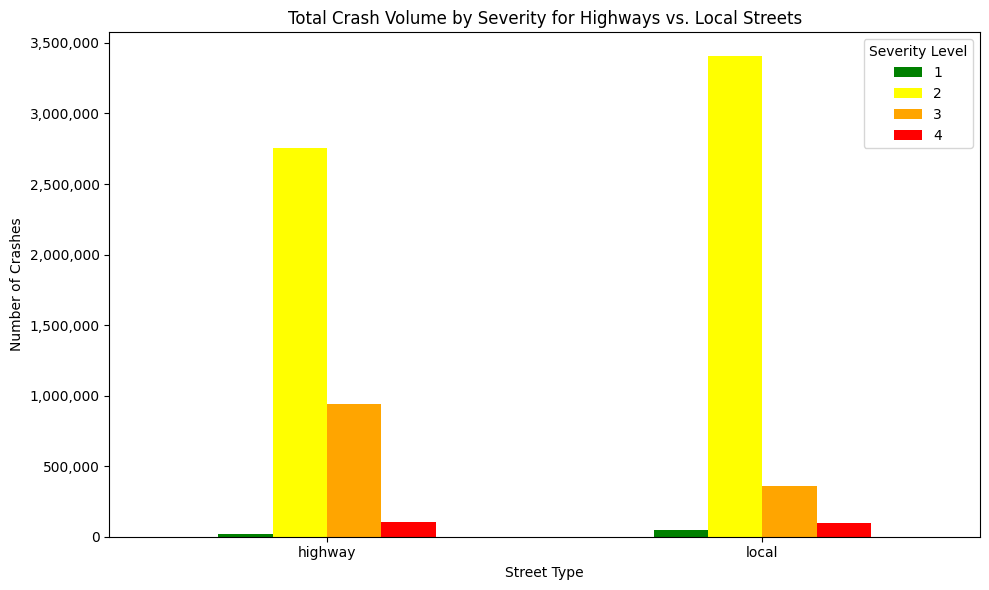

In [25]:
# Group the data by Street_Type and Severity
street_plot = data.groupby(['Street_Type', 'Severity']).size().unstack(fill_value=0)

# Plot the data in a grouped bar chart
ax = street_plot.plot(kind='bar', figsize=(10, 6), color=['green', 'yellow', 'orange', 'red'])
plt.title('Total Crash Volume by Severity for Highways vs. Local Streets')
plt.xlabel('Street Type')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=0)
plt.legend(title='Severity Level')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) # Add commas to the y-axis for better readability

plt.tight_layout()
plt.show()

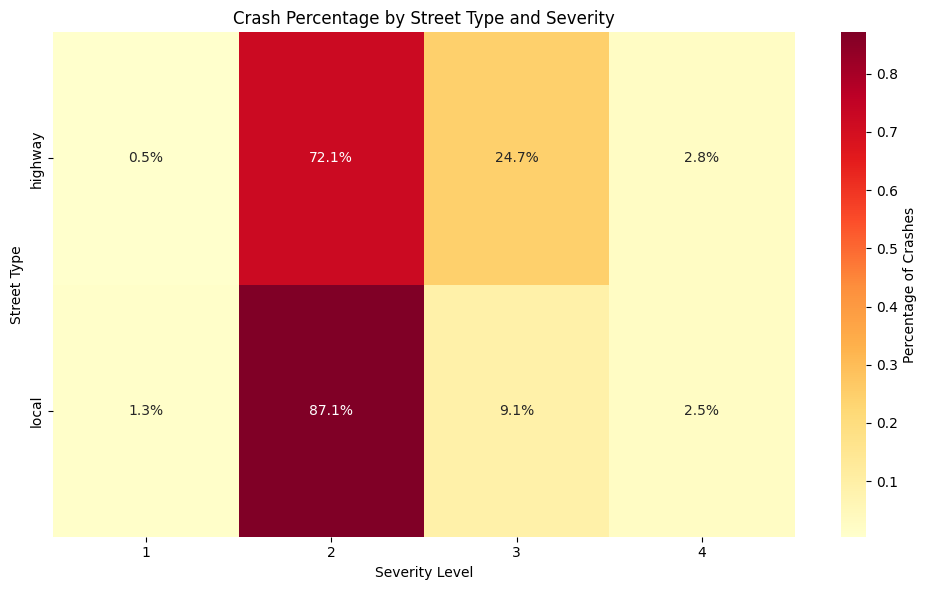

In [26]:
# Plot a heatmap as an alternate visualization of crash volume percentage by Street Type and Severity
street_heatmap = pd.crosstab(data['Street_Type'], data['Severity'], normalize='index')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(street_heatmap, 
            annot=True,
            fmt='.1%',
            cmap='YlOrRd',
            cbar_kws={'label': 'Percentage of Crashes'})

plt.title('Crash Percentage by Street Type and Severity')
plt.xlabel('Severity Level')
plt.ylabel('Street Type')

plt.tight_layout()
plt.show()

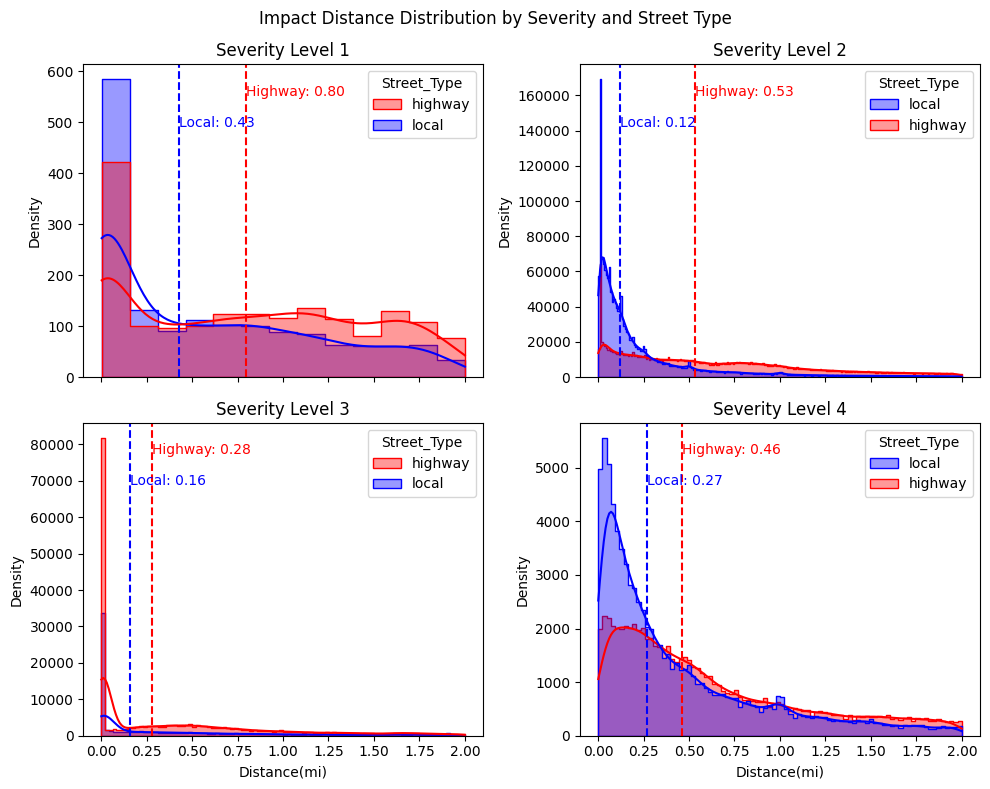

In [27]:
# Plot a histogram with medians of the impact distance of crashes by street type

# The vast majority of Distance values are equal to 0.00 miles, so filter these out for better visualization
# There is a tiny number of outliers above 2.0 miles, so filter these out for better visualization
data_distance = data[(data['Distance(mi)'] > 0) & (data['Distance(mi)'] <= 2)]

# Make a subplot for each severity level
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for i, severity in enumerate(severity_levels):
    ax = axes[i]
    
    # Filter data for just this severity level
    subset = data_distance[data_distance['Severity'] == severity]
    
    # Plot the histogram
    sns.histplot(data=subset,
                 x='Distance(mi)',
                 hue='Street_Type', 
                 element='step',
                 kde=True,
                 common_norm=False, 
                 palette={'highway': 'red', 'local': 'blue'}, 
                 alpha=0.4,
                 ax=ax)
    
    # Add lines and text to the specific subplot
    y_limit = ax.get_ylim()[1]
    
    # Calculate and plot median values
    highway_median = subset[subset['Street_Type'] == 'highway']['Distance(mi)'].median()
    local_median = subset[subset['Street_Type'] == 'local']['Distance(mi)'].median()
    ax.axvline(highway_median, color='red', linestyle='--')
    ax.text(highway_median, y_limit * 0.9, f'Highway: {highway_median:.2f}', color='red')
        
    ax.axvline(local_median, color='blue', linestyle='--')
    ax.text(local_median, y_limit * 0.8, f'Local: {local_median:.2f}', color='blue')

    ax.set_title(f'Severity Level {severity}')
    ax.set_ylabel('Density')

plt.suptitle('Impact Distance Distribution by Severity and Street Type')
plt.tight_layout()
plt.show()

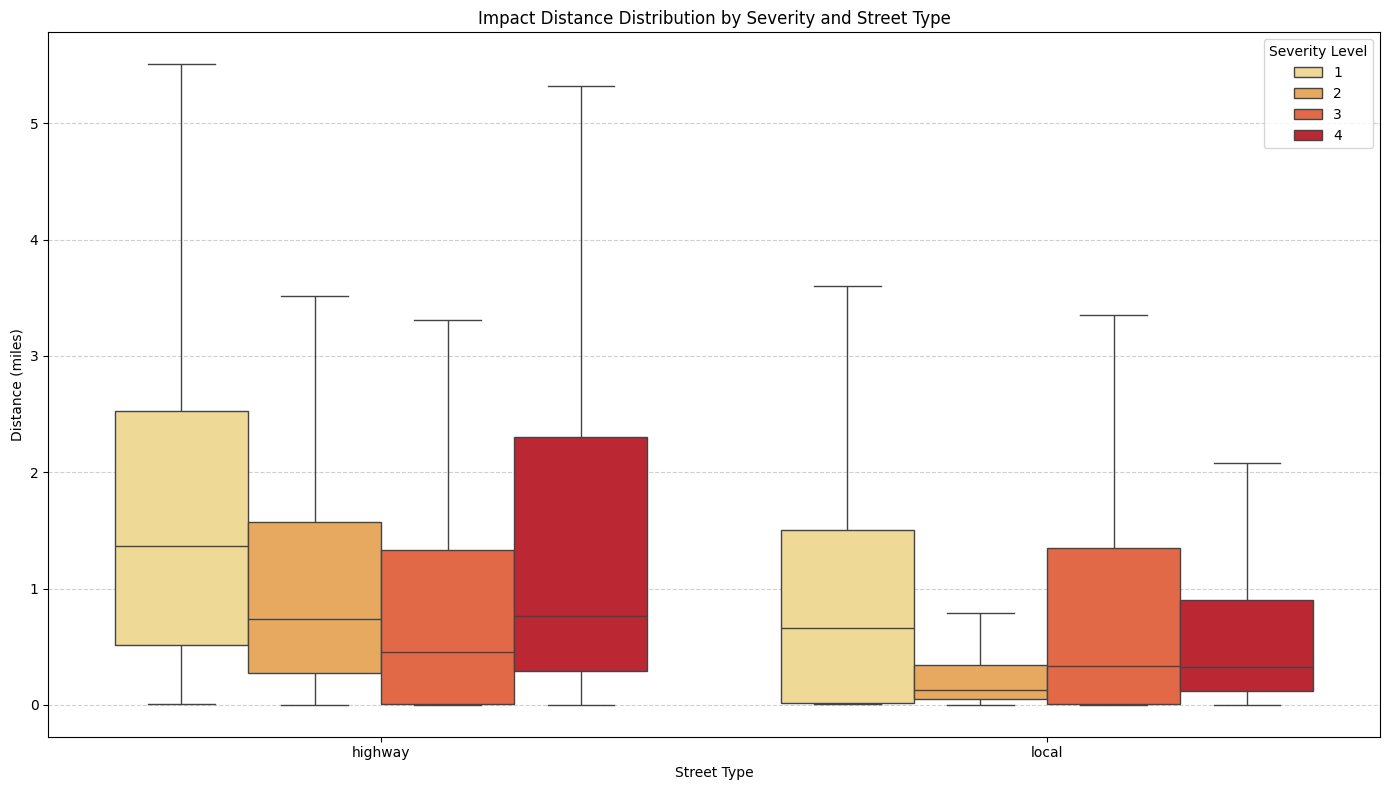

In [28]:
# Plot boxplots as an alternate visualization of impact distance distribution by street type and severity

# Treat Severity as a category
data['Severity_cat'] = data['Severity'].astype(str)

# Plot the box plots, again filtering out Distance=0 for better visualization, and use showfliers=False to remove outliers and make the chart readable
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=data[data['Distance(mi)']>0], 
    x='Street_Type', 
    y='Distance(mi)', 
    hue='Severity_cat', 
    palette='YlOrRd',
    showfliers=False,
    hue_order=['1', '2', '3', '4']
)

plt.title('Impact Distance Distribution by Severity and Street Type')
plt.xlabel('Street Type')
plt.ylabel('Distance (miles)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Severity Level', loc='upper right')

plt.tight_layout()
plt.show()

In [29]:
# The data distribution is heavily skewed and not normal, so use a Mann-Whitney U test to compare the ranks of the groups

# Filter and separate the groups, using the same cutoffs as in the chart above
highway_dist = data[(data['Street_Type'] == 'highway') & (data['Distance(mi)'] > 0) & (data['Distance(mi)'] <= 2)]['Distance(mi)']
local_dist = data[(data['Street_Type'] == 'local') & (data['Distance(mi)'] > 0) & (data['Distance(mi)'] <= 2)]['Distance(mi)']

# Run the Mann-Whitney U Test
stat, p_distance = mannwhitneyu(highway_dist, local_dist, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"P-value: {p_distance}")

if p_distance < 0.05:
    print('Because the p-value is less than 0.05, we reject the null hypothesis and can conclude there is a statistically significant relationship between the street type and the impact distance of the crash.')
else:
    print('Because the p-value is greater than 0.05, we fail to reject the null hypothesis and can conclude there is no statistically significant relationship between the street type and the impact distance of the crash.')

Mann-Whitney U Statistic: 2695388439370.00
P-value: 0.0
Because the p-value is less than 0.05, we reject the null hypothesis and can conclude there is a statistically significant relationship between the street type and the impact distance of the crash.


In [30]:
# Also calculate the median ratio to determine how much more of an impact distance there is for highway crashes vs. local crashes
highway_med = highway_dist.median()
local_med = local_dist.median()
ratio = highway_med / local_med

print(f"Highway crashes have an impact distance of {ratio:.2f}x more than local crashes.")

Highway crashes have an impact distance of 4.01x more than local crashes.


### Part 3: Analyze road design features for severity 4 crashes to determine how it relates to risk

In [42]:
# Select common road features
road_features = ['Stop', 'Traffic_Signal', 'Traffic_Calming', 'Crossing', 'Junction', 'Railway']

# Create a dictionary
risk_results = {}

# Calculate the risk based on the road feature and likelihood of having severity 4
for feature in road_features:
    feature_risk = data.groupby(feature)['Severity'].apply(lambda x: (x == 4).mean())
    risk_results[feature] = feature_risk

# Convert to a DataFrame
risk_df = pd.DataFrame(risk_results).T
risk_df.columns = ['Risk when Not Present', 'Risk when Present']
risk_df['Increase in Risk'] = risk_df['Risk when Present'] / risk_df['Risk when Not Present']

print(risk_df.sort_values(by='Increase in Risk', ascending=False))

                 Risk when Not Present  Risk when Present  Increase in Risk
Junction                      0.025727           0.036020          1.400099
Stop                          0.026487           0.026529          1.001582
Railway                       0.026516           0.023246          0.876669
Traffic_Signal                0.028029           0.017617          0.628534
Crossing                      0.027896           0.015444          0.553614
Traffic_Calming               0.026501           0.013030          0.491665


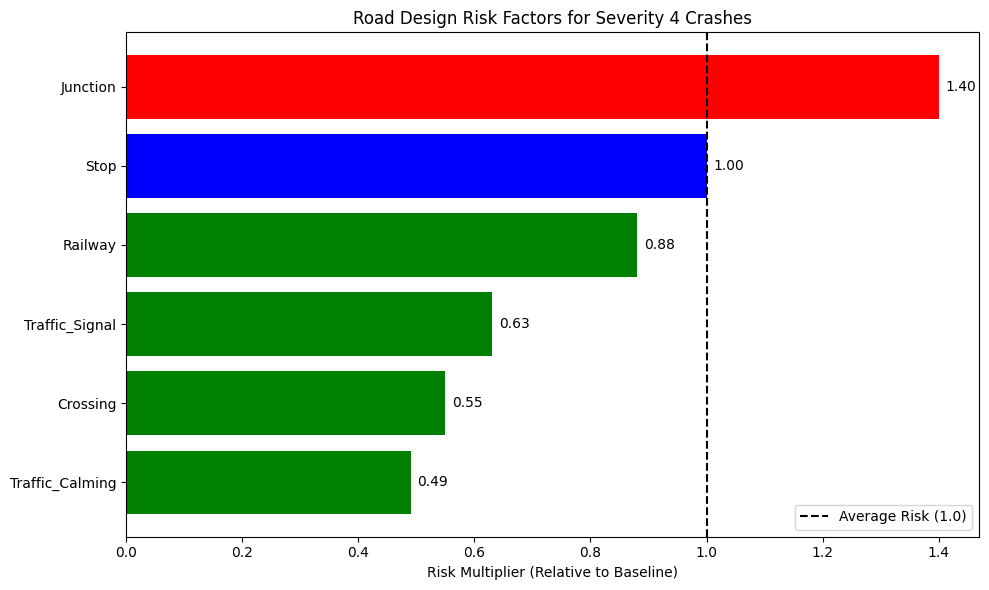

In [ ]:
# Define the data to plot, and round the values for cleaner visualization
road_plot = risk_df['Increase in Risk'].sort_values().round(2)

# Define what color to use for each bar based on its value in relation to 1 (neutral)
colors = []
for value in road_plot.values:
    if value > 1:
        colors.append('red')
    elif value < 1:
        colors.append('green')
    else:
        colors.append('blue')

# Plot the data, including a line at 1 for easy visual comparison
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(road_plot.index, road_plot.values, color=colors)
ax.axvline(1.0, color='black', linestyle='--', label='Average Risk (1.0)')
ax.bar_label(bars, fmt='%.2f', padding=5)
ax.set_title('Road Design Risk Factors for Severity 4 Crashes')
ax.set_xlabel('Risk Multiplier (Relative to Baseline)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [33]:
# Use logistic regression to determine how much each road feature increases the likelihood of a Severity 4 crash

# Create a binary target (1 for Severity 4, 0 for all other Severity levels)
data['Is_Severity_4'] = (data['Severity'] == 4).astype(int)

# For the boolean road_features defined previously, convert them to integers
X = data[road_features].astype(int)
X = sm.add_constant(X)
y = data['Is_Severity_4']

# Fit the model
model = sm.Logit(y, X)
results = model.fit()

# Print the results
print(results.summary())

# View the likelihood for each road feature by exponentiating the coef for each
likelihood = np.exp(results.params)
print(likelihood)

Optimization terminated successfully.
         Current function value: 0.121782
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          Is_Severity_4   No. Observations:              7728394
Model:                          Logit   Df Residuals:                  7728387
Method:                           MLE   Df Model:                            6
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                0.004348
Time:                        13:32:58   Log-Likelihood:            -9.4118e+05
converged:                       True   LL-Null:                   -9.4529e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.5580      0.003  -1389.646      0.000      -3.563      -3.553
Stop          

## Evaluation

### Business Insight/Recommendation 1 - Allocate Resources Based on Weekday and Time of Day

Part 1 of the analysis above looked at variations in day of week, combined with time of day, as it relates to the severity of crashes. As stated in the original source data, a severity of 1 "indicates the least impact on traffic (i.e., short delay as a result of the accident)" and a severity of 4 "indicates a significant impact on traffic (i.e., long delay)".

The low value for Cramer's V and the p-value of zero indicate that weekday plus time of day do matter, but there are definitely additional factors contributing. The heatmaps showing weekday and time of day for each severity level clearly show variation though.

For severity 1, 2, and 3, crashes are concentrated on weekdays between 7am and 9am, and between 4pm and 6pm, clearly corresponding to rush hour hours, where there is a high volume of cars on the road. As a result, local governments should ensure that resources related to clearing smaller crashes -- such as tow trucks and police officers -- are readily available during these times. This would help to clear those smaller crashes off of the road quickly, so that traffic congestion doesn't continue to build up and potentially lead to additional crashes.

For severity 4, crashes are most concentrated between 3pm and 5pm on weekdays, but are more generally spread out throughout the daytime hours of weekdays. These crashes are most likely caused by other factors besides just rush hour traffic volume. This could be weather conditions, poor road design, or human factors like speeding or distracted driving.

### Business Insight/Recommendation 2 - Allocate Resources to Redirect Traffic Away from Crashes to Minimize Impact Distance

In Part 2 of the analysis above, the charts for Impact Distance Distribution, within each severity level, show that the median impact distance of crashes on highways is larger than the median impact distance on local streets. This makes sense logically, since highways are more likely to have additional cars that are either involved in the crash themselves, or are rubbernecking around the crash to see what is happening, both of which could contribute to the impact distance.

The distribution plots also show that at all severity levels, the impact distance is more predictably low for local streets, versus being less predictable on highways. Even after removing the spikes for crashes with an impact distance of 0, crashes at all severity levels on local streets still have a spike at just above 0, and fall off quickly from there. Highway crashes also have a spike at just above 0 for all severity levels except 4, but do not decrease as sharply from there. This predictability, or lack there of, is also shown in the box plots. For local crashes, especially for severity levels 2 and 4, the "box" part of the plots are very small in height, showing that half of the values are contained within that range. The "boxes" for highway crashes are much taller, indicating more variability within the middle half of values.

In order to help mitigate this, for highways, crash responses should focus on not just clearing the crash itself, but also on clearing rubbernecking or other driver slowdowns that can contribute to the impact distance of even minor crashes. This could include deploying additional personnel to direct traffic around crashes, using temporary cones to divert traffic into the shoulder as an additional path, and using programmable signs to announce detours to drivers before they get close to the crash location.

For local streets, although the impact distance is incredibly low at all severity levels, similar mitigation strategies should still be used. Besides attempting to clear crashes quickly with tow trucks, responders should focus on redirecting traffic in order to reduce backups from rubbernecking. Local roads generally provide easier options for detouring around a specific intersection or other location, so responders should proactively redirect traffic in order to keep cars moving, and further reduce the impact distance.

### Business Insight/Recommendation 3 - Add Road Safety Features that Mitigate Crashes

Part 3 of the analysis above looked at six common road features and their relationship to crashes with a severity of 4. As determined above, these crashes are more likely caused by factors besides just heavy traffic due to weekday rush hour.

The risk of severity 4 crashes at each road feature was calculated by looking at all crashes where a particular road feature was present (in other words, "True" in the data), and then how likely the crash is to be severity 4 compared to a crash that happened elsewhere. As shown in the chart above, the features Traffic Calming, Crossing, and Traffic Signal reduce the risk of severity 4 crashes. This makes sense logically, because these types of road features force drivers to pay more attention and slow down. Conversely, the road feature Junction increase the risk of severity 4 crashes. This also makes sense logically, because junctions are areas when cars are moving in different directions and crossing each other, which provides additional opportunities for crashes.

The visual conclusions from the chart are backed up by using logistic regression on the data, which controls for confounding variables, unlike the chart which looked at each feature individually. The positive coefficients for Junction and Railway show that these increase the risk, while the negative coefficients for Traffic Signal, Traffic Calming, and Crossing show that these decrease the risk.

In order to mitigate crashes, road safety features should be added, especially at or near junctions. Adding traffic signals to junctions, or doing more significant overhauls like converting them to roundabouts or changing turning patterns with jughandles, would help to modify driver behavior and reduce the risk of severity 4 crashes.

### Tableau Dashboard link

In [41]:
# Save DataFrame with specific original and derived columns to CSV for use in Tableau dashboard

columns_for_export = [
    'ID',
 'Severity',
 'Distance(mi)',
 'City',
 'County',
 'State',
 'Weather_Condition',
 'Crossing',
 'Junction',
 'Railway',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Sunrise_Sunset',
 'Year',
 'Month',
 'Day',
 'Day_of_Week',
 'Hour',
 'Street_Type',
 'Day_and_Time',
]

data_export = data[columns_for_export]

data_export.to_csv('crash_data.csv', index=False)

Dashboard: https://public.tableau.com/app/profile/katie.kavett/viz/CarCrashAnalysis_17760175015370/Homepage#1

## Conclusion

The analysis done in this project shows that the severity of car crashes is not random, and is directly impacted by factors like weekday and time of day, and by road design features. To reduce car crashes and their impacts, multiple strategies are recommended:

1. Allocate resources based on known "hot spots" in time. During morning and evening rush hours of weekdays, ensuring there is enough personnel and equipment -- both police/EMT and tow trucks -- to respond to multiple crashes in the same two hour window can help ensure crashes are cleared quickly. This in turn can lead to less delays and additional crashes, saving people time and money. Having enough personnel to respond to multiple crashes in the same window of time can also ensure that people involved in the second, third, etc. crash are not potentially facing additional injury due to longer response times from EMTs.
2. For crashes on both highways and local streets, response personnel should also focus on diverting traffic around crashes to reduce their impact distance. The exact methods may vary based on whether the crash took place on a highway or local street, but can include measures like traffic control from police officers, blocking off streets entirely to cause a detour, using cones to direct cars into the shoulder as an additional lane, etc. Especially on highways, where crashes have a much more unpredictable impact distance, using additional strategies to minimize the impact distance would save time and money for other drivers on the road.
3. Especially at locations where severity 4 crashes have occured, road design should be reviewed and improved. Traffic calming, crosswalks, and traffic lights all reduce severity 4 crashes; while junctions increase them. Road design teams should review junctions and determine which standard four-way intersections can be changed to roundabouts, jughandles, protected turning lanes, etc. in order to minimize crashes. Additionally, roads with long straight sections lead drivers to speed, so adding design features like traffic calming, crosswalks, and traffic lights can slow drivers down and keep them more focused on the road and their surroundings, also leading to reduced crashes.

Integrating these data-driven insights can help stakeholders shift from a more reactive stance to a more proactive way of deploying resources and reducing crashes before they happen.

### Next Steps

There is a variety of additional analysis that could be completed if additional features were included in the data set:
* The data does not specify the type of vehicle, so I completed the above analysis assuming all vehicles were relatively similar cars. Including data about car vs. truck vs. other vehicle (motorcycle, etc.), as well as size of vehicle (sedan vs. pickup truck, moving van vs. 18-wheeler, etc.) could provide additional insights.
* The data does not specify the speed limit where the crash occurred. This can be loosely inferred through the derived column about the type of street (highways have speed limits between 50 and 80 mph, and local streets have speed limits between 5 and 50 mph), but this data could be analyzed alongside severity to see if these features are correlated.
* The data does not include whether the crash resulted in any injuries and/or fatalities. This information would give a clearer picture of the total severity and impact to human life of the crash.
* The data does not specify how many vehicles were involved in the crash, and if only one vehicle, whether the crash involved a tree, median, or other stationary object. Having this data would allow for comparisons between single-vehicle versus multi-vehicle crashes.

There is also additional analysis that could be done with the existing data, given more time.
* Crashes could be analyzed with more of a focus on their location. State, county, and zip code data is already included, so the analysis could be "zoomed in" to look at just a particular region of the country.
* Comparisons could be done between multiple regions, to determine which have lower crash rates, and attempt to learn from their strategies. This type of analysis would also likely need to include additional data about population density, since a town with a small population would be expected to have fewer crashes than a large city, simply by nature of the number of vehicles located there.
* Crash rates for regions that are known to have adverse weather during particular seasons could be looked at. For example, looking at winters with a lot of snow in New England, or hurricane season in parts of the South. If higher rates of crashes are found during these seasons with adverse weather, a recommendation could be made to even further emphasize to drivers to stay off the roads.
* The data spans the period of time before, during, and after COVID shutdowns. The data could be examined to see how the time period during the height of COVID shutdowns impacted the number and severity of crashes.